Please upload an image file (e.g., JPG or PNG)...


Saving IMG_20240711_223434_213 (1).jpg to IMG_20240711_223434_213 (1).jpg
Using image file: IMG_20240711_223434_213 (1).jpg


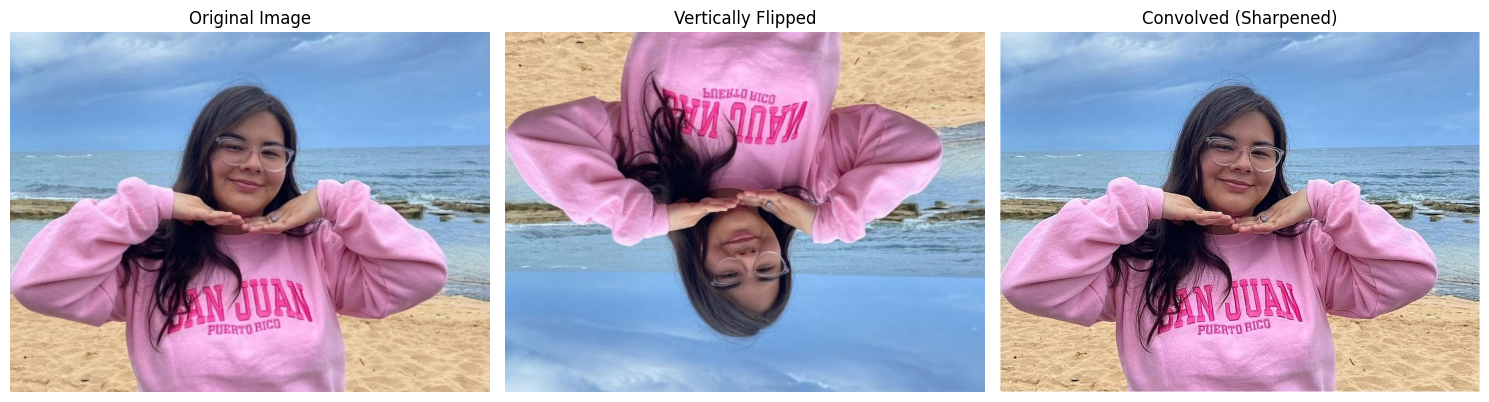

In [ ]:
"""
Arlette Torres
COSC 4330-01/5330-01 Multimedia Processing
Instructor: Prof. JIANGJIANG (JANE) LIU
Homework 6-I: Vertical Flip and Convolution on an Image (Colab Version)

This Colab notebook cell:
1. Lets the user upload an image file.
2. Loads the uploaded image.
3. Vertically flips the image using a custom function.
4. Applies a 3x3 convolution kernel (sharpen filter) using a custom convolution function.
5. Shows the original, flipped, and convolved images in matplotlib plots.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
from google.colab import files

# =========================
#  Helper image functions
# =========================

def vertical_flip(image_array):
    """
    Vertically flip an image.
    Input:  image_array (H x W x C) or (H x W)
    Output: flipped image (same shape)
    """
    # Reverse the order of rows (flip upside down)
    return image_array[::-1, ...]


def convolve_single_channel(channel, kernel):
    """
    Apply 2D convolution on a single-channel (grayscale) image.
    Uses zero-padding around the borders.

    channel: 2D numpy array (H x W)
    kernel:  2D numpy array (kH x kW)
    """
    kh, kw = kernel.shape
    pad_h = kh // 2
    pad_w = kw // 2

    # Zero pad
    padded = np.pad(channel,
                    ((pad_h, pad_h), (pad_w, pad_w)),
                    mode='constant',
                    constant_values=0)

    out = np.zeros_like(channel, dtype=np.float64)

    # Convolution
    for i in range(channel.shape[0]):
        for j in range(channel.shape[1]):
            region = padded[i:i + kh, j:j + kw]
            out[i, j] = np.sum(region * kernel)

    # Clip values into [0,1] for display
    out = np.clip(out, 0.0, 1.0)
    return out


def apply_convolution(image_array, kernel):
    """
    Apply convolution to an image.
    If the image is RGB (H x W x 3), apply the kernel to each channel.
    If the image is grayscale (H x W), convolve once.
    """
    if image_array.ndim == 2:
        # Grayscale image
        return convolve_single_channel(image_array, kernel)
    elif image_array.ndim == 3:
        # Color image: process each channel
        h, w, c = image_array.shape
        output = np.zeros_like(image_array, dtype=np.float64)
        for ch in range(c):
            output[:, :, ch] = convolve_single_channel(image_array[:, :, ch], kernel)
        output = np.clip(output, 0.0, 1.0)
        return output
    else:
        raise ValueError("Unsupported image shape. Expected 2D or 3D array.")


# =========================
#  Main Colab workflow
# =========================

# 1. Upload an image from your computer
print("Please upload an image file (e.g., JPG or PNG)...")
uploaded = files.upload()

# Get the first uploaded filename
image_path = next(iter(uploaded))
print(f"Using image file: {image_path}")

# 2. Load the image
image = imread(image_path)

# Convert to float64 in [0,1] if necessary
if image.dtype == np.uint8:
    image = image.astype(np.float64) / 255.0
else:
    image = image.astype(np.float64)

# 3. Vertically flip the image
flipped_image = vertical_flip(image)

# 4. Define a 3x3 convolution kernel (example: sharpen)
sharpen_kernel = np.array([[0, -1,  0],
                           [-1, 5, -1],
                           [0, -1,  0]], dtype=np.float64)

# 5. Apply convolution to the original image
convolved_image = apply_convolution(image, sharpen_kernel)

# 6. Plot and show the images
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(flipped_image, cmap='gray')
plt.title("Vertically Flipped")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(convolved_image, cmap='gray')
plt.title("Convolved (Sharpened)")
plt.axis("off")

plt.tight_layout()
plt.show()
